In [1038]:
import numpy as np
from PIL import Image,ImageDraw,ImageFont

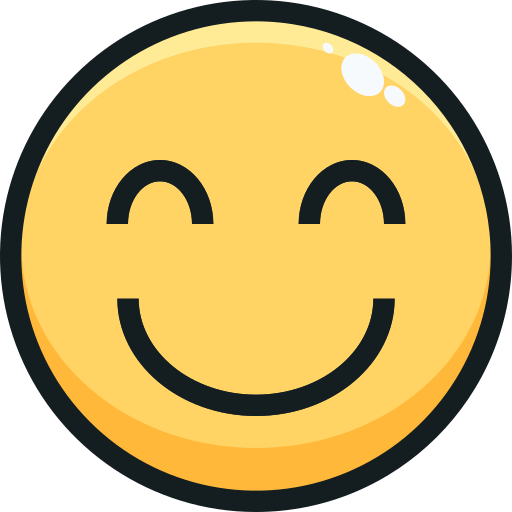

In [1039]:
img = Image.open('/content/smile.png')
img

In [1040]:
photo = np.array(Image.open('/content/smile.png'))
photo

array([[[0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        ...,
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]],

       [[0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        ...,
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]],

       [[0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        ...,
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]],

       ...,

       [[0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        ...,
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]],

       [[0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        ...,
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]],

       [[0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        ...,
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]]], dtype=uint8)

In [1041]:
print(photo.shape)
print(photo.ndim)
print(photo.size)


(512, 512, 4)
3
1048576


In [1042]:
photo = 0.299*photo[:,:,0] + 0.587*photo[:,:,1] + 0.114*photo[:,:,2]
photo

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [1043]:
print(photo.shape)
print(photo.ndim)
print(photo.size)

(512, 512)
2
262144


In [1044]:
height = photo.shape[0]
width = photo.shape[1]
print(height)
print(width)

512
512


In [1045]:
block = 10
height = height // block * block
width = width // block * block

#crop to make it divisible by 10
photo = photo[:height,:width]
photo = photo.reshape(height//block, block, width//block, block)

In [1046]:
print(photo.shape)
print(photo.ndim)
print(photo.size)

(51, 10, 51, 10)
4
260100


In [1047]:
photo = photo.mean(axis=(1,3))
photo

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [1048]:
print(photo.shape)
print(photo.ndim)
print(photo.size)

(51, 51)
2
2601


In [1049]:
chars = "@%#*+=-:. "

In [1050]:
indices = np.interp(photo,(0,255), (0,len(chars)-1)).astype(int)
indices

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [1051]:
chars = list(chars)
chars = np.array(chars)
chars

array(['@', '%', '#', '*', '+', '=', '-', ':', '.', ' '], dtype='<U1')

In [1052]:
char_photo = chars[indices]
print(char_photo)

[['@' '@' '@' ... '@' '@' '@']
 ['@' '@' '@' ... '@' '@' '@']
 ['@' '@' '@' ... '@' '@' '@']
 ...
 ['@' '@' '@' ... '@' '@' '@']
 ['@' '@' '@' ... '@' '@' '@']
 ['@' '@' '@' ... '@' '@' '@']]


In [1053]:
print(photo.shape)
print(photo.ndim)
print(photo.size)

(51, 51)
2
2601


#ارسم الحروف دي في صورة جديدة

In [1054]:
font = ImageFont.load_default()
char_w, char_h = 6, 11
rows = height // block
cols = width // block
img = Image.new('RGB', (cols * char_w, rows * char_h), 'white')
draw = ImageDraw.Draw(img)
for y in range(rows):
  for x in range(cols):
    draw.text((x*char_w, y*char_h), char_photo[y,x],fill = 'black',font = font)

In [1055]:
img.save("photo_text.png")

#تلوّن كل حرف بلون البكسل الأصلي

In [1056]:
img_rgba = Image.open('/content/smile.png')
background = Image.new('RGB', img_rgba.size, 'white')
background.paste(img_rgba, mask=img_rgba) #if its RGBA convert it to RGB
color_photo = np.array(background)

In [1057]:
print(color_photo.shape)
print(color_photo.ndim)
print(color_photo.size)

(512, 512, 3)
3
786432


In [1058]:
color_photo = color_photo[:height, :width,:3]  #to make it RGB
color_photo = color_photo.reshape(height//block, block, width//block, block, 3)
color_photo = color_photo.mean(axis=(1,3)).astype(int)
color_photo

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]

In [1059]:
print(color_photo.shape)
print(color_photo.ndim)
print(color_photo.size)

(51, 51, 3)
3
7803


In [1060]:
font = ImageFont.load_default(size=17)
img = Image.new('RGB',(char_w * cols, char_h*rows),'white')
draw = ImageDraw.Draw(img)

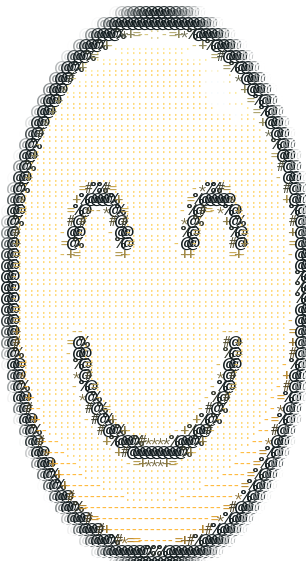

In [1061]:
for y in range(rows):
  for x in range(cols):
    r,g,b = color_photo[y,x]
    ch = char_photo[y,x]
    draw.text((x * char_w , y * char_h), ch, fill=(r,g,b),font = font)
img.save('photo_colored.png')
img